# Working Memory Report — HRM on MazeHard

This notebook inspects one artifact-backed HRM MazeHard rollout. It traces the model's behaviour from final prediction, through recurrent prediction refinement, into H/L latent-state dynamics and termination.

The emphasis is mechanistic rather than distributional: each figure is tied to a concrete traced rollout and should be read as case-level evidence.


### Figure provenance

All figures displayed in this notebook are **canonical report artifacts**: they were generated by the reporting pipeline, indexed in the report-run manifest, and are safe as benchmark evidence. The notebook does not generate figures from raw traces or define new benchmark scores.

If future notebook-derived comparison views are added, they will be explicitly labelled as `derived` (computed from existing `MetricRecord` or report artifacts) or `exploratory` (computed from raw traces for hypothesis generation) and saved under `artifacts/notebook_views/`, never into `artifacts/reports/`.

See `spec/spec-benchmark-suite.md` §3 "Figure Provenance Taxonomy" for canonical definitions.



## 1. Report Identity and Execution Status

| Field              | Value                                               |
| ------------------ | --------------------------------------------------- |
| Model family       | HRM v1 (primary), HRM v2 (comparison, if available) |
| Checkpoint         | `checkpoints/hrm-v1/eval-weights-only.pt`           |
| Task               | MazeHard (solution-path prediction)                 |
| Split              | `test`                                              |
| Eval slice         | 1 diagnostic case (`mazehard_n1`)                   |
| ReportRun root     | `artifacts/reports/hrm_v1/mazehard_n1`              |
| Eval artifact root | `artifacts/evaluation/hrm_v1/mazehard_n1`           |
| Created            | TBD                                                 |
| Device / precision | CPU (diagnostic regime)                             |
| Seed               | Not recorded in provenance                          |


## 2. Scientific Question

We inspect whether an HRM-style recurrent controller shows evidence of useful internal computation on a MazeHard rollout. The report asks four questions:

1. Does the predicted solution improve across recurrent steps?
2. Can task-relevant path content be read from the recurrent states (z_H and z_L) while the model is reasoning?
3. Do the high-level and low-level recurrent states show distinct dynamics?
4. Does the rollout terminate as expected under the current fixed-budget evaluation mode?

This order mirrors the intended analysis: behaviour first, content readout second, recurrent dynamics third, termination fourth.

**Section conclusion (pending).** Each question is addressed in its corresponding evidence section (§§7–10). The answers are preliminary and limited to a single diagnostic case.

### 2.1 Paper Context: Wang HRM + Whittington Tale

**Wang et al. 2025 (HRM)** answers an implementation question: how can a model perform latent recurrent reasoning efficiently? Their proposal is hierarchical slow/fast recurrent computation with adaptive halting.

**Whittington et al. 2025 (Tale)** answers a representation question: what should PFC working memory contain? Their answer is structured, controllable activity-based variables (activity slots).

**This notebook** evaluates whether HRM latent recurrent states provide evidence for PFC-like structured working-memory dynamics during structured reasoning. MazeHard supports indirect tests through z_H/z_L persistence, H/L dissociation, prediction behaviour, and adaptive computation.

### Role Summary

| Paper                   | Role in this notebook                                           |
| ----------------------- | --------------------------------------------------------------- |
| Wang et al. 2025        | Primary: model architecture and dynamics                        |
| Whittington et al. 2025 | Primary: representational target for working-memory diagnostics |


## 3. Task and Benchmark — MazeHard

MazeHard is a structured pathfinding task requiring multi-step reasoning over a maze-like symbolic environment. The model receives the maze layout as input and must predict the solution path token-by-token.

### Why MazeHard for PFC/HRM

- Tests hierarchical recurrent computation (Wang HRM).
- Requires multi-step state maintenance and local action selection.
- Provides `z_H`, `z_L`, and halting traces for dynamics analysis.

### Limitations for isolated slot-addressability tests

MazeHard supports indirect working-memory evidence (state persistence, H/L dissociation, adaptive control) but does not isolate slot-addressable memory from reasoning. Stronger tests would require cue-dependent recall, item-position binding, counterfactual cue interventions, or delay-period distractors.

The report uses one MazeHard evaluation case. The task is to predict a solution-path overlay for the maze input.

### Case metadata

| Field             | Value                                                   |
| ----------------- | ------------------------------------------------------- |
| Regime            | `mazehard_n1`                                           |
| Case ID           | `mazehard-test-0000`                                    |
| Target-path cells | (populated from trace)                                  |
| Rollout steps     | 16                                                      |
| Vocabulary        | 6 tokens (obstacle, empty, start, target, path, unused) |

### Benchmark Parameters

| Parameter           | Value                              |
| ------------------- | ---------------------------------- |
| Task family         | `mazehard`                         |
| Split               | `test`                             |
| Cases in this slice | 1 (diagnostic, not full benchmark) |
| Provider            | `MazeHardReplayProvider`           |


## 4. Model Internals Inspected

The HRM architecture separates high-level context/plan states (`z_H`) from low-level computation states (`z_L`) via a hierarchical recurrent design. This report inspects the following trace variables captured during offline evaluation.

| Trace key               | Shape          | Description                         | Evidence section |
| ----------------------- | -------------- | ----------------------------------- | ---------------- |
| `pred/solution_overlay` | `(T, B, N)`    | Predicted solution overlay per step | §7               |
| `pfc/z_H`               | `(T, B, S, D)` | High-level recurrent state          | §8               |
| `pfc/z_L`               | `(T, B, S, D)` | Low-level recurrent state           | §9               |
| `act/halted`            | `(T, B)`       | Rollout termination signal          | §10              |

These traces support a case-level mechanistic reading of behaviour, dynamics, and termination.


In [ ]:
from ehc_sn.reporting import open_report, ReportCollection, build_or_load_report_collection
from IPython.display import Image, Markdown, display

# Report paths
HRM_V1_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/hrm_v1/mazehard_n1"
HRM_V2_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/hrm_v2/mazehard_n1"

# Load reports (individual references needed by figure display cells)
hrm_v1_report = open_report(HRM_V1_REPORT_PATH)
hrm_v2_report = open_report(HRM_V2_REPORT_PATH)

# Build a ReportCollection for comparison views
collection = build_or_load_report_collection(
    [hrm_v1_report, hrm_v2_report],
    title="Working Memory Report — HRM on MazeHard",
    question=(
        "Do HRM recurrent states carry task-relevant path content, "
        "and do HRM v1 and HRM v2 differ in benchmark performance?"
    ),
)

collection.display_header()
collection.display_evidence_plan(primary_metric="token_accuracy")
collection.display_binding_table()

HRM v1 report summary:
	 report:   /home/borja/ehc-sn/artifacts/reports/hrm_v1/mazehard_n1
	 metrics:  7
	 figures:  12
HRM v2 report summary:
	 report:   /home/borja/ehc-sn/artifacts/reports/hrm_v2/mazehard_n1
	 metrics:  7
	 figures:  12


## 5. Training Dynamics and Checkpoint Selection

| Field                     | Status                                                                                                                                                                                                                      |
| ------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| ReportRun-backed          | ❌ Pending                                                                                                                                                                                                                  |
| Source needed             | Training logs / TensorBoard / Lightning metrics                                                                                                                                                                             |
| Current blocker           | Training logs are not yet ingested into the ReportRun artifact                                                                                                                                                              |
| Interpretation constraint | Results below describe the selected checkpoint only. They do **not** establish convergence, and the reader cannot distinguish learned structure from overfit memorisation on this small eval slice without training curves. |

**Required diagnostics (future):**

- `train/loss`, `val/loss`
- Prediction accuracy over training steps
- Loss components (token prediction, halting, auxiliary)
- Learning rate schedule
- Gradient norm history

> Until training curves are available, the checkpoint selection is unvalidated. Results in the sections below describe a single checkpoint, not a converged model.


## 6. Behavioural Performance

This section reports scalar metrics for the traced rollout. These provide an aggregate view of final prediction and should be read together with the prediction-over-time figures in §7.

**Chance baseline:** token-level uniform accuracy is low, but depends on vocabulary size and maze difficulty.

> High token accuracy can coexist with low path recall because the overlay is background-dominated. The path-specific figures in §7 are therefore necessary for interpretation.

### HRM v2 aggregate metrics: comparison table

The table below reports the available scalar metrics for both runs.

| Metric              | HRM v1     | HRM v2     |
| ------------------- | ---------- | ---------- |
| `token_accuracy`    | 0.962      | **0.516**  |
| `loss`              | 1.79       | **213.78** |
| `n_token_correct`   | 866 / 900  | 464 / 900  |

The evaluated case has 117 path cells out of 900 total grid cells (~13%). A trivial always-background classifier would achieve ~87% raw token accuracy. The author should compare the reported values against this baseline when assessing model performance. Before interpreting any HRM v2 metric as a model-capability difference, the following should be verified: checkpoint integrity, evaluation config parity between v1 and v2, label distribution, and task-objective compatibility.

The sections below report v2 metrics for completeness. The mechanistic working-memory comparison (§10.2) is deferred until v2 evaluation validity is confirmed.

### Primary benchmark score

The primary benchmark score for MazeHard is `token_accuracy` (canonical name: `MAZEHARD_PRIMARY_METRIC_NAME`). This is distinct from the HRM v2 RL training reward signal, which is a stop-time reward used only during training. Both models are evaluated on the same task-level benchmark.

In [ ]:
# Primary score comparison view
collection.display_primary_metrics(primary_metric="token_accuracy")

In [48]:
# Display metrics
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    if report is None:
        continue
    metrics = report.metrics()
    print(f"\n{label}:")
    for m in metrics:
        hb = " (higher is better)" if m.higher_is_better else ""
        print(f"  {m.metric:<30s} {m.value:<8.3f} {m.unit or '—':<10s} {hb}")

print()
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    if report is None:
        continue
    s = report.summary()
    print(
        f"{label}: {s['model_family']}, {s['metric_count']} metrics, "
        f"{s['figure_count']} figures"
    )


HRM v1:
  token_accuracy                 0.962    ratio       (higher is better)
  sequence_accuracy              0.962    ratio       (higher is better)
  sequence_exact                 0.000    ratio       (higher is better)
  n_token_correct                866.000  count       (higher is better)
  n_token_total                  900.000  count      
  n_sequence_completed           1.000    count      
  n_sequence_eligible            16.000   count      

HRM v2:
  token_accuracy                 0.516    ratio       (higher is better)
  sequence_accuracy              0.516    ratio       (higher is better)
  sequence_exact                 0.000    ratio       (higher is better)
  n_token_correct                464.000  count       (higher is better)
  n_token_total                  900.000  count      
  n_sequence_completed           1.000    count      
  n_sequence_eligible            16.000   count      

HRM v1: hrm-v1, 7 metrics, 12 figures
HRM v2: hrm-v2, 7 metrics, 12 figur

**Author interpretation pending.**
Interpret the printed metrics in terms of:
- how the aggregate values compare across HRM v1 and HRM v2,
- whether the metrics are above the background baseline (~87% for always-background on this maze),
- the limitation that aggregate metrics alone do not distinguish correct path structure from background-dominated agreement.

**Section conclusion.** These scalar metrics provide a compact performance summary. They should be read together with path-specific and step-wise diagnostics in §7 before drawing conclusions about solution quality.

## 7. Prediction Examples

This section addresses question 1 from §2: does the predicted solution improve across recurrent steps? It provides behavioural evidence — per-step comparisons between ground-truth solution paths and model-predicted paths — before the latent-dynamics analysis in §§8–9.

### 7.1 Task layout

**`mazehard_task_layout`** shows the MazeHard input grid and target solution path for the traced case. This figure provides the spatial context for interpreting the prediction-evolution and accuracy-over-steps figures below. Examine the maze layout, start/target positions, and target-path geometry.

HRM v1 — mazehard_task_layout (case=mazehard_n1)


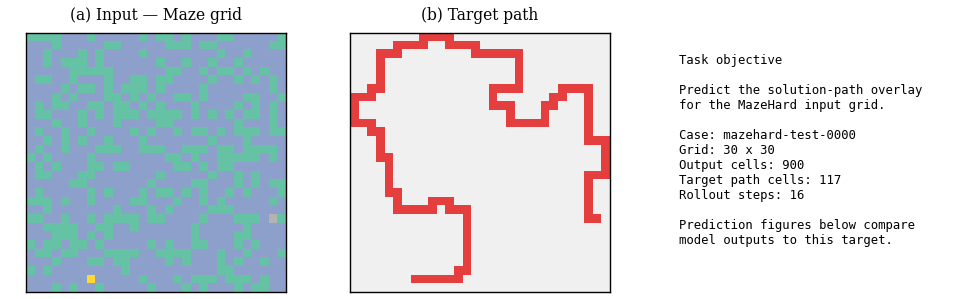

In [49]:
# --- Task layout
for label, report in [("HRM v1", hrm_v1_report)]:
    entry = report.figure_entry("mazehard_task_layout", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mazehard_task_layout not available.")
    print()

**Author interpretation pending.**
Interpret this figure in terms of:
- the maze layout, start/target positions, and target-path geometry,
- whether the task requires multi-step planning (e.g. dead ends, detours),
- the distribution of path vs. background cells (class imbalance).

### 7.2 Prediction evolution mosaic

**`mazehard_prediction_evolution`** shows how the predicted solution overlay changes across recurrent rollout steps. Each panel corresponds to one recurrent step; the sequence reveals whether the prediction becomes more accurate over time.

> **Qualitative single-case illustration.** The quantitative test of improvement over recurrent computation is in §7.3.

HRM v1 — mazehard_prediction_evolution (case=mazehard_n1)


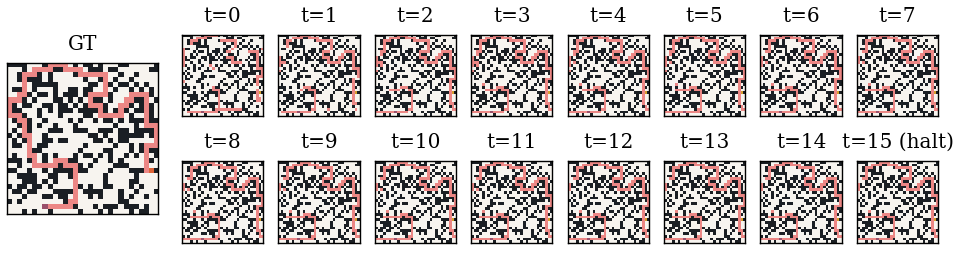


HRM v2 — mazehard_prediction_evolution (case=mazehard_n1)


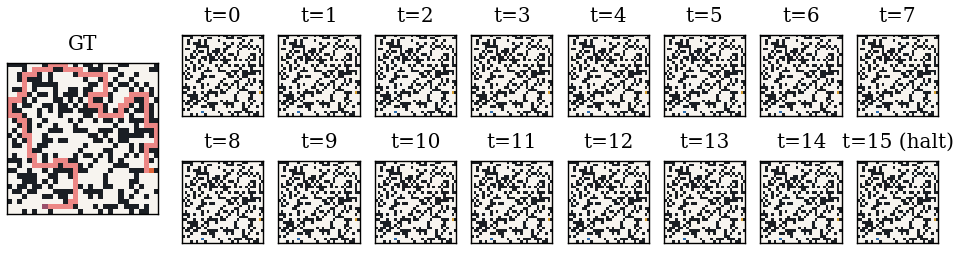

In [50]:
# --- PFC Latent ....
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("mazehard_prediction_evolution", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mazehard_prediction_evolution not available.")
    print()

**Author interpretation pending.**
Interpret this figure in terms of:
- whether the predicted path converges toward the target across steps,
- what type of error (near-miss, globally wrong, looping) is visible, if any,
- whether HRM v1 and HRM v2 show qualitatively different refinement patterns,
- whether early steps contain partial or noisy predictions that are later refined.

### 7.3 Prediction accuracy over steps

**`prediction_accuracy_over_steps`** quantifies prediction quality at each recurrent step. The x-axis is the recurrent step. Panel A: **token accuracy** (cell-wise agreement with ground truth) — a trivial always-background classifier would achieve ~87% on this maze (117 path cells out of 900 total), so high raw accuracy does not imply good path prediction. Panel B: **target-path recall** (fraction of true-path cells correctly predicted; does not penalise false positives). Panel C: **summary comparison** of initial, best, and final accuracy and recall across the rollout. Higher is better for all panels.

This is the quantitative counterpart to the evolution mosaic in §7.2. It addresses question 1 from §2: does the predicted solution improve across recurrent steps?

HRM v1 — prediction_accuracy_over_steps (case=mazehard_n1)


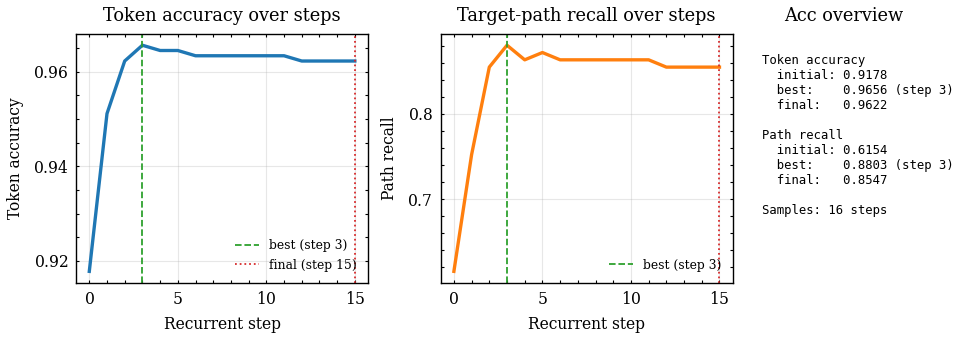


HRM v2 — prediction_accuracy_over_steps (case=mazehard_n1)


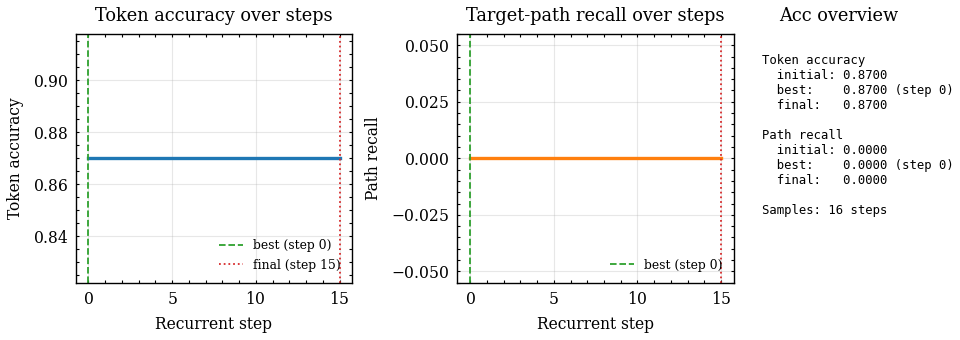

In [ ]:
# --- Token accuracy across recurrent steps and halting decision ---
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry(
        "prediction_accuracy_over_steps", preferred_format="png"
    )
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: prediction_accuracy_over_steps not available.")
    print()

**Author interpretation pending.**
Interpret this figure in terms of:
- whether accuracy improves over recurrent steps (answering §2, question 1),
- whether the improvement saturates before the final step,
- how initial vs. final accuracy compares across HRM v1 and HRM v2,
- the gap between token accuracy (Panel A) and path recall (Panel B) — a large gap would indicate background-dominated agreement masking poor path prediction.

**Section conclusion.** This section provides the behavioural metrics needed to assess whether the predicted solution improves over recurrent steps. The final determination should be based on the accuracy-over-steps trend observed in the figure.

## 8. H/L Latent Dynamics — Overview

This section addresses question 3 from §2: do the high-level and low-level recurrent states show distinct dynamics? It provides an initial comparison of H and L latent-state magnitude and update behaviour before the finer-grained residual analysis in §9.

**`pfc_latent_dynamics`** tracks three quantities over recurrent steps. Panel A: **state magnitude** (L2 norm of z_H and z_L per step) — larger values indicate higher activation but do not imply semantic content. Panel B: **update magnitude** (L2 norm of the step-to-step delta) — larger deltas mean faster change; comparing H and L reveals their relative update rates. Panel C: **average L/H update ratio** — values above 1 indicate that low-level states update more aggressively than high-level states, consistent with the hierarchical design. The x-axis in all panels is the recurrent step.

> **Caveat:** This is the broad dynamics overview. Semantic claims about planning or working-memory content require separate probe analyses.

HRM v1 — pfc_latent_dynamics (case=mazehard_n1)


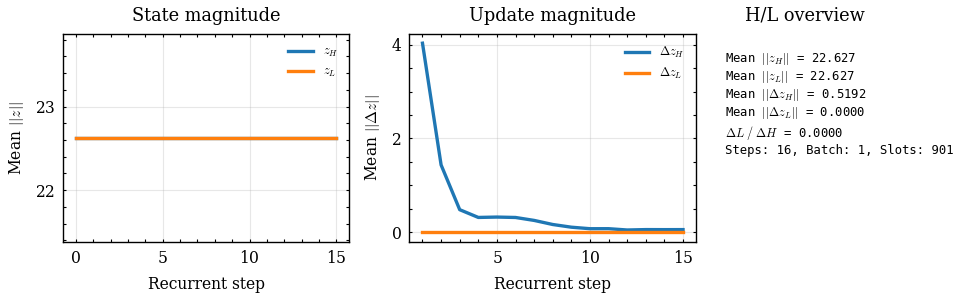


HRM v2 — pfc_latent_dynamics (case=mazehard_n1)


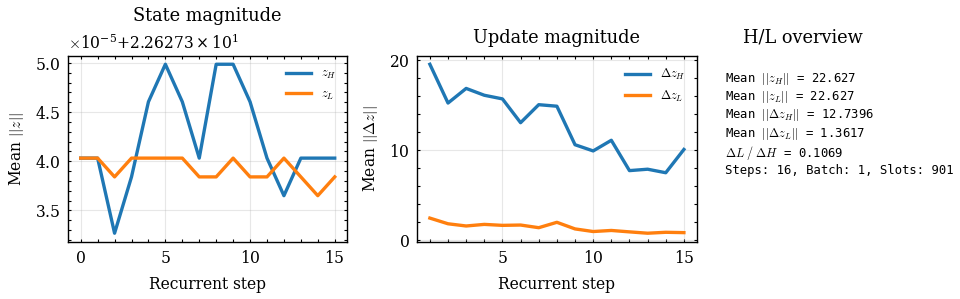

In [51]:
# --- PFC Latent ....
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("pfc_latent_dynamics", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: pfc_latent_dynamics not available.")
    print()

**Author interpretation pending.**
Interpret this figure in terms of:
- whether state magnitudes remain stable or drift over the rollout,
- whether update magnitudes differ between H and L states,
- whether the L/H update ratio shows faster low-level dynamics.

**Section conclusion.** This section provides the diagnostic information needed to assess whether H and L states show distinct dynamics. The residual analysis in §9 adds a finer-grained view.

## 9. H/L Latent Dynamics — Residuals

This section continues the analysis of question 3 from §2 with a finer-grained diagnostic of H/L update dynamics.

**`h_l_residuals_over_steps`** shows three quantities over recurrent steps. Panel A: **forward residuals** (L2 norm of the step-to-step update for z_H and z_L separately) — larger values indicate larger state changes at that step. Panel B: **consecutive-step cosine similarity** — values near 1 mean the state changed little in direction; near 0 or negative means a large directional shift. Panel C: **L/H residual separation ratio** — values above 1 indicate that low-level residuals dominate high-level residuals, supporting the hierarchical design where L updates faster than H.

> **Caveat:** The current evaluation is fixed-budget. The figure describes continuous recurrent dynamics, not learned ACT cycles or reset events.

HRM v1 — h_l_residuals_over_steps (case=mazehard_n1)


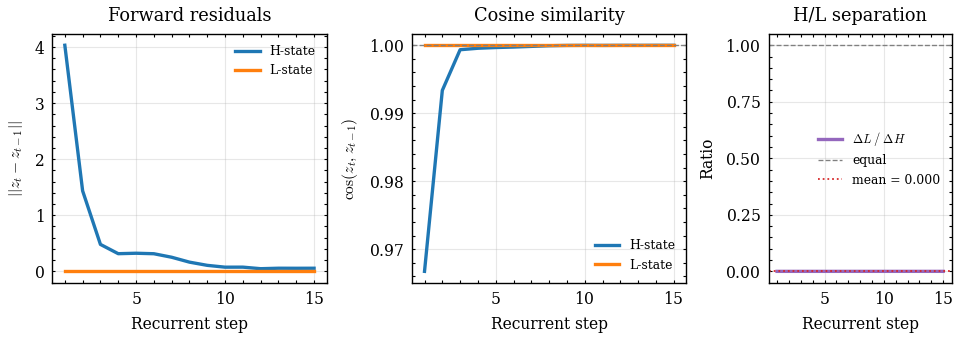


HRM v2 — h_l_residuals_over_steps (case=mazehard_n1)


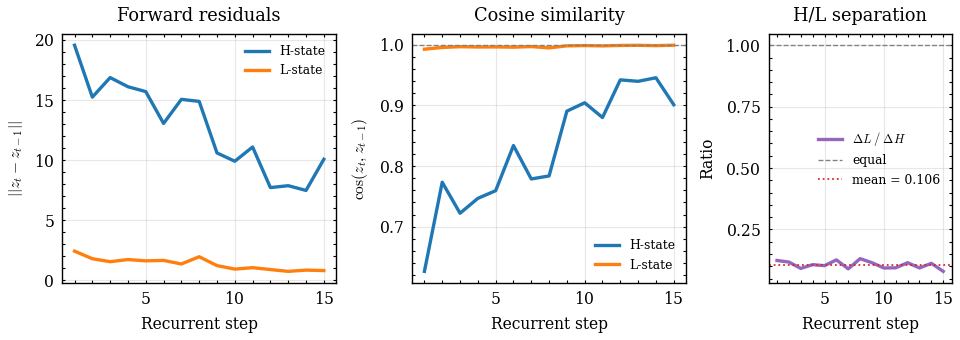

In [52]:
# --- L-State ....
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("h_l_residuals_over_steps", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: h_l_residuals_over_steps not available.")
    print()

**Author interpretation pending.**
Interpret this figure in terms of:
- whether H and L residuals differ in magnitude (answering §2, question 3),
- whether cosine similarity indicates stability or oscillation,
- whether the separation ratio shows consistent H/L dissociation.

**Section conclusion.** This section provides the residual diagnostics for assessing H/L dissociation. The observed separation should be evaluated by the author — a larger L residual than H residual would indicate faster low-level updates; similar residuals would suggest weaker separation between the recurrent streams.

## 10. Halting and Adaptive Computation

This section addresses question 4 from §2: does the rollout terminate as expected under the current fixed-budget evaluation mode? The halt trace should be used to verify the termination signal.

In the current fixed-budget evaluation mode, termination occurs at the configured maximum recurrent step. The halt trace is therefore a termination diagnostic rather than evidence of learned adaptive computation. Learned early stopping would require a separate evaluation mode with learned halting enabled.

> **Note:** The `halting_timeline` figure referenced in §12 is not displayed in this notebook. Verification of the termination signal currently relies on the scalar metrics and code output rather than a dedicated visualisation.

**Section conclusion.** In the fixed-budget regime, a halt at the final recurrent step is expected. The author should verify that the rollout length matches the configured budget and confirm that no early-stopping behaviour occurs despite the fixed-budget setting.

## 10.2 Path-content readout from recurrent states

This section addresses question 2 from §2: can task-relevant path content be read from the recurrent states (z_H and z_L)? The probe is available **for HRM v1 only**; HRM v2 lacks the required artifact.

For each recurrent step, a linear logistic regression classifier predicts whether each grid cell belongs to the target solution path using only that cell's hidden vector — no spatial context or maze layout. The model was never trained on this task.

**Reading the figure:** The y-axis is balanced accuracy — chance is 0.50, values above indicate linear decodability of path membership. The x-axis is the recurrent step. Compare z_H and z_L: a z_H ≫ z_L gap is consistent with z_H carrying more path content; z_H ≈ z_L ≫ 0.50 suggests distributed content. The probe establishes decodability, not causal use or slot structure.

HRM v1 — pfc_path_memory_probe (case=mazehard_n1)


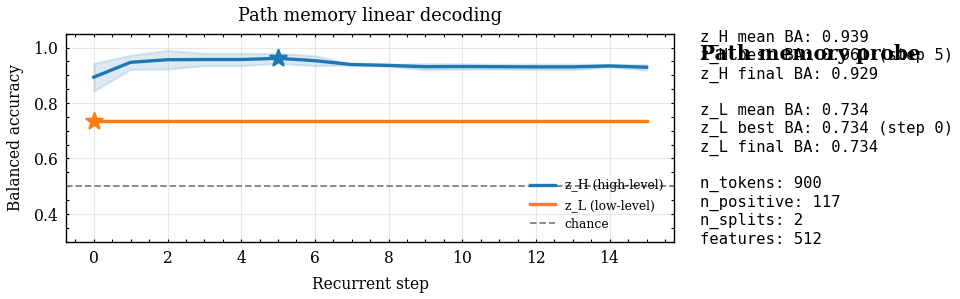


HRM v2: pfc_path_memory_probe not available.



In [54]:
# --- PFC Path-Memory Probe ---
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("pfc_path_memory_probe", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        missing_reason = ""
        if label == "HRM v2":
            missing_reason = " — eval artifact missing probes/pfc_path_memory_probe.npz"
        print(f"{label}: pfc_path_memory_probe not available{missing_reason}.")
    print()

**Author interpretation pending.**
Interpret this figure in terms of:
- whether balanced accuracy exceeds 0.50 for either state (answering §2, question 2),
- the gap between z_H and z_L,
- the trend across recurrent steps.

The probe method, interpretation guide, and limitations are described in §10.2.

**Section conclusion.** This probe provides a linear decodability test for path content in z_H and z_L. Any working-memory claim would require additional evidence for causal use, capacity limits, slot structure, or controllability beyond what decodability alone establishes.

## 11. Evidence Gaps and Next Steps

The above sections provide case-level diagnostic information for several necessary ingredients — prediction improvement, H/L dynamics, and path-content decodability — but leave several important gaps unresolved.

### Current evidence gaps

- **Missing HRM v2 probe artifact.** The `pfc_path_memory_probe` comparison between HRM v1 and HRM v2 is unavailable because the v2 eval artifact does not contain `probes/pfc_path_memory_probe.*`. This must be resolved upstream by re-running the v2 eval with probe computation enabled, then rebuilding the v2 report.
- **HRM v2 metrics require verification.** The v2 aggregate metrics (`token_accuracy ≈ 0.516`, `loss ≈ 213.78`) differ substantially from v1. The author should verify checkpoint integrity, eval config parity, and task-objective compatibility before interpreting these as a model-capability difference.
- **Working-memory probe comparison.** Even when the v2 probe is available, the probe establishes only linear decodability. Causal use, slot structure, capacity limits, and controllability remain untested for both models.

### Deferred analyses

- **Multi-case summaries** for distributional behaviour and failure rates.
- **Population participation ratio** once enough independent cases are available.
- **Learned halting analysis** under an evaluation mode with learned halting enabled.
- **Flat RNN/GRU baseline** to test whether dynamics are HRM-specific.
- **Causal perturbation** (masking or intervening on z_H / z_L) to establish whether the path content detected by the probe is *used* by the model.
- **Slot-structure and subspace tests** (cross-temporal decoding, cue-controlled retrieval, subspace factorization) to distinguish distributed representation from structured working memory.
- **Cue-recall evaluation** for isolated slot-addressability tests.

### Priority Order for Next Implementation

1. **Multi-case artifacts** — enables distributional behaviour analysis.
2. **Causal perturbation** — establishes whether probed content is behaviourally relevant.
3. **Flat RNN/GRU baseline** — enables specificity claim.
4. **Learned halting eval** — enables adaptive-computation analysis.
5. **Slot-structure and cue-recall tests** — enables isolated WM controllability evidence.

In [ ]:
# Figure availability comparison view
collection.display_figure_availability()

In [ ]:
# Evidence status comparison view
collection.display_evidence_status(
    evidence_axes=[
        {
            "axis": "Task context",
            "figure_id": "mazehard_task_layout",
        },
        {
            "axis": "Recurrent prediction",
            "figure_id": "prediction_accuracy_over_steps",
        },
        {
            "axis": "H/L dynamics",
            "figure_id": "pfc_latent_dynamics",
        },
        {
            "axis": "Probe: path content",
            "figure_id": "pfc_path_memory_probe",
        },
        {
            "axis": "Termination",
            "status": {"HRM v1": "available (prose)", "HRM v2": "available (prose)"},
        },
    ],
)

## 12. Evidence Summary

| Evidence axis        | Figure(s)                                                         | What is supported                                                  | v1  | v2        |
| -------------------- | ----------------------------------------------------------------- | ------------------------------------------------------------------ | --- | --------- |
| Task context         | `mazehard_task_layout`                                            | Input grid and target path can be inspected spatially              | ✅  | ✅        |
| Recurrent prediction | `mazehard_prediction_evolution`, `prediction_accuracy_over_steps` | Prediction changes and quality can be tracked over recurrent steps | ✅  | ✅ ⚠️     |
| H/L dynamics         | `pfc_latent_dynamics`, `h_l_residuals_over_steps`                 | High- and low-level recurrent states can be compared over rollout  | ✅  | ✅        |
| Probe: path content  | `pfc_path_memory_probe`                                           | Path membership linearly decodable from recurrent states           | ✅  | ❌ missing |
| Termination          | `halting_timeline`                                                | Fixed-budget termination is verified                               | ✅  | ✅        |

**Key:**
- ✅ = evidence axis is available.
- ❌ missing = eval artifact does not contain the required probe data.
- ⚠️ = evidence exists but v2 aggregate metrics suggest a possible checkpoint/eval validity problem (see §6 warning).

The report supports case-level mechanistic inspection for HRM v1 across all evidence axes. The v1/v2 probe comparison is unavailable until the v2 eval artifact is repaired. Population-level robustness, failure distributions, and representational geometry require separate aggregate artefacts.

## 13. Reproducibility

### Artifact Paths

| Artifact                | Path                                       |
| ----------------------- | ------------------------------------------ |
| HRM v1 ReportRun        | `artifacts/reports/hrm_v1/mazehard_n1`     |
| HRM v2 ReportRun        | `artifacts/reports/hrm_v2/mazehard_n1`     |
| HRM v1 eval artifacts   | `artifacts/evaluation/hrm_v1/mazehard_n1`  |
| HRM v2 eval artifacts   | `artifacts/evaluation/hrm_v2/mazehard_n1`  |
| HRM v1 checkpoint       | `checkpoints/hrm-v1/eval-weights-only.pt`  |
| HRM v2 checkpoint       | `checkpoints/hrm-v2/eval-weights-only.pt`  |
| HRM v1 model config     | `config/models/hrm-v1-base.toml`           |
| HRM v2 model config     | `config/models/hrm-v2-base.toml`           |
| HRM v1 report spec      | `config/reporting/hrm_v1_mazehard_n1.toml` |
| HRM v2 report spec      | `config/reporting/hrm_v2_mazehard_n1.toml` |
| MazeHard benchmark spec | `spec/spec-benchmark-suite.md`             |

### Commands to Reproduce

```bash
# HRM v1 — Generate evaluation artifacts with all diagnostic traces (n=1)
python scripts/evaluation/run_eval.py \
    --model-family hrm-v1 \
    --checkpoint checkpoints/hrm-v1/eval-weights-only.pt \
    --config config/evaluation/hrm-v1-mazehard.toml \
    --task mazehard \
    --provider-ref ehc_sn.tasks.mazehard.providers.MazeHardReplayProvider \
    --regime-id mazehard_n1 --regime-kind diagnostic \
    --trace-keys pfc/z_H,pfc/z_L,act/halted,pred/solution_overlay \
    --output artifacts/evaluation/hrm_v1/mazehard_n1 \
    --device cpu

# HRM v1 — Generate ReportRun from eval artifacts
python scripts/reporting/run_report.py \
    --config config/reporting/hrm_v1_mazehard_n1.toml

# HRM v2 — Generate evaluation artifacts with all diagnostic traces (n=1)
python scripts/evaluation/run_eval.py \
    --model-family hrm-v2 \
    --checkpoint checkpoints/hrm-v2/eval-weights-only.pt \
    --config config/evaluation/hrm-v2-mazehard.toml \
    --task mazehard \
    --provider-ref ehc_sn.tasks.mazehard.providers.MazeHardReplayProvider \
    --regime-id mazehard_n1 --regime-kind diagnostic \
    --trace-keys pfc/z_H,pfc/z_L,act/halted,pred/solution_overlay \
    --output artifacts/evaluation/hrm_v2/mazehard_n1 \
    --device cpu

# HRM v2 — Generate ReportRun from eval artifacts
python scripts/reporting/run_report.py \
    --config config/reporting/hrm_v2_mazehard_n1.toml
```

### Known Reproducibility Gaps

| Gap                            | Impact                             |
| ------------------------------ | ---------------------------------- |
| Git commit SHA not recorded    | Cannot pin the exact code version  |
| Checkpoint SHA256 not recorded | Cannot verify checkpoint integrity |